<a href="https://colab.research.google.com/github/hykim-1/Study/blob/main/GRU_smartphone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import numpy as np, pandas as pd
from keras.utils import to_categorical
import matplotlib.pyplot as plt, seaborn as sns
import keras
from keras import layers
import tensorflow as tf
from sklearn.metrics import f1_score, classification_report, accuracy_score, confusion_matrix, precision_recall_fscore_support

SEED=42
np.random.seed(SEED); tf.random.set_seed(SEED)

In [ ]:
# ----- Loader (동일) -----
def load_file(fp):
    df = pd.read_csv(fp, header=None, delim_whitespace=True)
    return df.values

def load_group(files, prefix=''):
    return np.dstack([load_file(prefix+name) for name in files])

def load_dataset_group(group, prefix=''):
    fp = prefix + group + '/Inertial Signals/'
    files = [f'total_acc_{a}_{group}.txt' for a in ['x','y','z']]
    files+= [f'body_acc_{a}_{group}.txt'  for a in ['x','y','z']]
    files+= [f'body_gyro_{a}_{group}.txt' for a in ['x','y','z']]
    X = load_group(files, fp); y = load_file(prefix+group+f'/y_{group}.txt')
    return X, y

def load_dataset(prefix=''):
    base = '/content/drive/MyDrive/Colab Notebooks/UCI HAR Dataset/UCI HAR Dataset/'
    trainX, trainy = load_dataset_group('train', base)
    testX,  testy  = load_dataset_group('test',  base)
    trainy = trainy - 1; testy = testy - 1
    print("Shapes:", "trainX",trainX.shape,"trainy",trainy.shape,"| testX",testX.shape,"testy",testy.shape)
    return trainX, trainy, testX, testy

X_train, y_train, X_test, y_test = load_dataset()
num_classes = len(np.unique(y_train))
y_train_oh = to_categorical(y_train); y_test_oh = to_categorical(y_test)
timesteps, n_channels = X_train.shape[1], X_train.shape[2]
input_shape = (timesteps, n_channels)

/tmp/ipython-input-2867525225.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(fp, header=None, delim_whitespace=True)
/tmp/ipython-input-2867525225.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(fp, header=None, delim_whitespace=True)
/tmp/ipython-input-2867525225.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(fp, header=None, delim_whitespace=True)
/tmp/ipython-input-2867525225.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(fp, header=None, delim_whitespace=True)
/tmp/ipython-input-2867525225.py:3: FutureWarning: T

Shapes: trainX (7352, 128, 9) trainy (7352, 1) | testX (2947, 128, 9) testy (2947, 1)


In [ ]:
# ----- GRU -----
def build_gru(input_shape, num_classes):
    inp = keras.Input(shape=input_shape)
    x = layers.GRU(128, return_sequences=True)(inp)
    x = layers.Dropout(0.3)(x)
    x = layers.GRU(64)(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inp, out, name="GRU")

model = build_gru(input_shape, num_classes)
model.summary()

Model: "GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 128, 128)       │        53,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91,014 (355.52 KB)

 Trainable params: 91,014 (355.52 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
opt = keras.optimizers.Adam(1e-3)
model.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])
callbacks=[keras.callbacks.EarlyStopping(monitor="loss", patience=3, restore_best_weights=True)]
history = model.fit(X_train, y_train_oh, epochs=30, batch_size=64, verbose=2, callbacks=callbacks)

probs = model.predict(X_test, verbose=0)
y_pred = probs.argmax(axis=1); y_true = y_test.flatten()
acc = accuracy_score(y_true, y_pred); f1m = f1_score(y_true, y_pred, average="macro")
print(f"[TEST] Acc={acc:.4f} | Macro-F1={f1m:.4f}")
print("\n[TEST] Classification Report"); print(classification_report(y_true, y_pred, digits=4))

Epoch 1/30
115/115 - 6s - 54ms/step - accuracy: 0.5008 - loss: 1.1746
Epoch 2/30
115/115 - 1s - 11ms/step - accuracy: 0.6956 - loss: 0.7254
Epoch 3/30
115/115 - 2s - 15ms/step - accuracy: 0.8949 - loss: 0.2961
Epoch 4/30
115/115 - 2s - 20ms/step - accuracy: 0.9321 - loss: 0.1877
Epoch 5/30
115/115 - 1s - 11ms/step - accuracy: 0.9418 - loss: 0.1587
Epoch 6/30
115/115 - 1s - 11ms/step - accuracy: 0.9437 - loss: 0.1480
Epoch 7/30
115/115 - 1s - 12ms/step - accuracy: 0.9415 - loss: 0.1472
Epoch 8/30
115/115 - 1s - 11ms/step - accuracy: 0.9476 - loss: 0.1320
Epoch 9/30
115/115 - 1s - 12ms/step - accuracy: 0.9483 - loss: 0.1289
Epoch 10/30
115/115 - 1s - 12ms/step - accuracy: 0.9509 - loss: 0.1201
Epoch 11/30
115/115 - 1s - 13ms/step - accuracy: 0.9490 - loss: 0.1285
Epoch 12/30
115/115 - 2s - 16ms/step - accuracy: 0.9521 - loss: 0.1160
Epoch 13/30
115/115 - 2s - 14ms/step - accuracy: 0.9399 - loss: 0.1672
Epoch 14/30
115/115 - 1s - 12ms/step - accuracy: 0.9509 - loss: 0.1199
Epoch 15/30
115

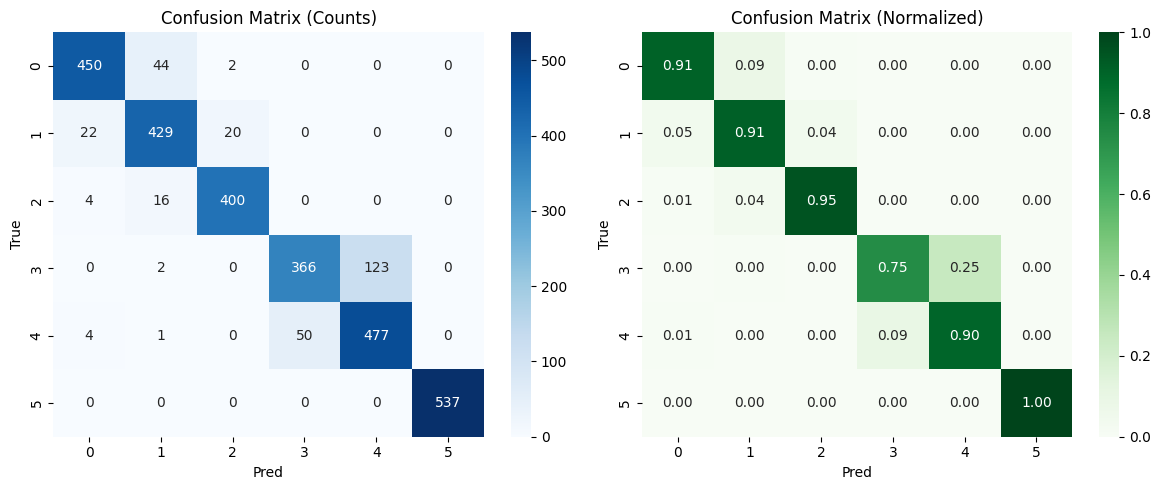

In [ ]:
cm = confusion_matrix(y_true, y_pred); cm_norm = confusion_matrix(y_true, y_pred, normalize='true')
plt.figure(figsize=(12,5))
plt.subplot(1,2,1); sns.heatmap(cm, annot=True, fmt='d', cmap='Blues'); plt.title('Confusion Matrix (Counts)'); plt.xlabel('Pred'); plt.ylabel('True')
plt.subplot(1,2,2); sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens'); plt.title('Confusion Matrix (Normalized)'); plt.xlabel('Pred'); plt.ylabel('True')
plt.tight_layout(); plt.show()

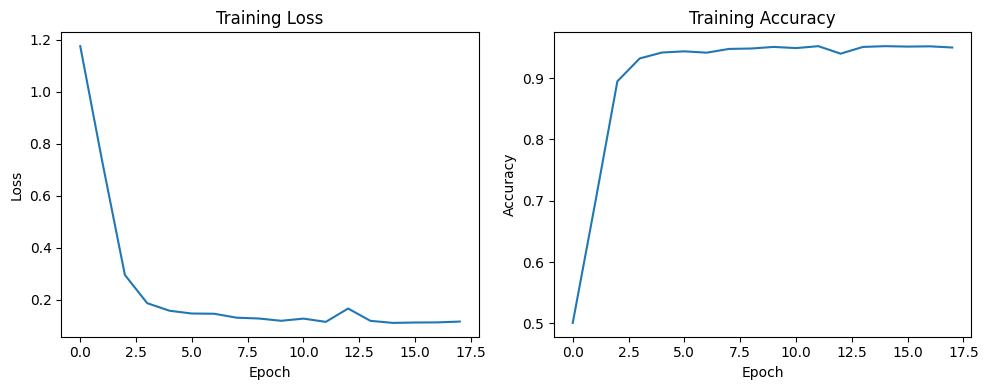

In [9]:
hist = history.history
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.plot(hist.get('loss', [])); plt.title('Training Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.subplot(1,2,2); plt.plot(hist.get('accuracy', [])); plt.title('Training Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.tight_layout(); plt.show()

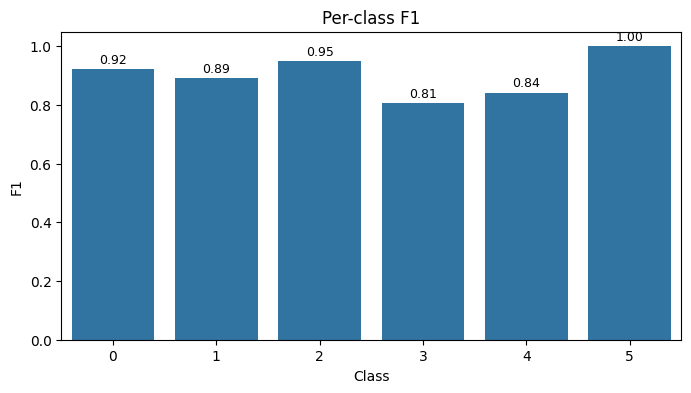


TF: 2.19.0 | Keras: 3.10.0 | Backend: tensorflow


In [10]:
prec, rec, f1s, support = precision_recall_fscore_support(y_true, y_pred, zero_division=0)
classes = np.arange(len(f1s))
plt.figure(figsize=(8,4)); sns.barplot(x=classes, y=f1s); plt.title('Per-class F1'); plt.xlabel('Class'); plt.ylabel('F1')
for i, v in enumerate(f1s): plt.text(i, v+0.01, f"{v:.2f}", ha='center', va='bottom', fontsize=9)
plt.ylim(0,1.05); plt.show()

print("\nTF:", tf.__version__, "| Keras:", keras.__version__, "| Backend:", keras.backend.backend())